# Simple EDA


## Task: Trick classification


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
MANIFEST_DIR = DATA_DIR / "manifests"
TASK_MANIFEST_DIR = MANIFEST_DIR / "trick_classification"
CLIPS_DIR = DATA_DIR / "clips"
TRICK_TASK_COLUMNS = ["trick", "execution_score", "key_foot", "person"]
SCORE_TASK_COLUMNS = ["execution_score", "trick", "key_foot", "person"]


### Load manifests


In [2]:
split_paths = {
    "train": TASK_MANIFEST_DIR / "train.jsonl",
    "val": TASK_MANIFEST_DIR / "val.jsonl",
    "test": TASK_MANIFEST_DIR / "test.jsonl",
}
split_frames = {}
for split, path in split_paths.items():
    if not path.exists():
        raise FileNotFoundError(
            f"Missing manifest: {path}. Run the data pipeline first."
        )
    df = pd.read_json(path, lines=True)
    df["split"] = split
    split_frames[split] = df

manifest_df = pd.concat(split_frames.values(), ignore_index=True)
print("Manifest rows per split:")
for split, df in split_frames.items():
    print(f"  {split}: {len(df)}")
manifest_df.head()

Manifest rows per split:
  train: 455
  val: 58
  test: 57


,video_id,s3_path,trick,key_foot,person,execution_score,execution_explanation,split
0,25-11-17 21-54-30 5744-00.07.44.435-00.07.47.4...,s3://aitraf/clips/25-11-17 21-54-30 5744-00.07...,ao-soul,right,Vilius,NaN,None,train
1,25-12-01 20-52-05 5968-00.17.03.043-00.17.08.1...,s3://aitraf/clips/25-12-01 20-52-05 5968-00.17...,fs-savanah,right,Henrikas,NaN,None,train
2,25-12-01 20-39-09 5966-00.01.45.454-00.01.52.3...,s3://aitraf/clips/25-12-01 20-39-09 5966-00.01...,soul,right,Henrikas,NaN,None,train
3,25-10-31 19-54-19 5689-00.04.30.676-00.04.36.3...,s3://aitraf/clips/25-10-31 19-54-19 5689-00.04...,top-soul,right,Henrikas,NaN,None,train
4,25-12-01 20-39-09 5966-00.01.28.215-00.01.34.0...,s3://aitraf/clips/25-12-01 20-39-09 5966-00.01...,soul,left,Henrikas,NaN,None,train


### Feature distribution across splits


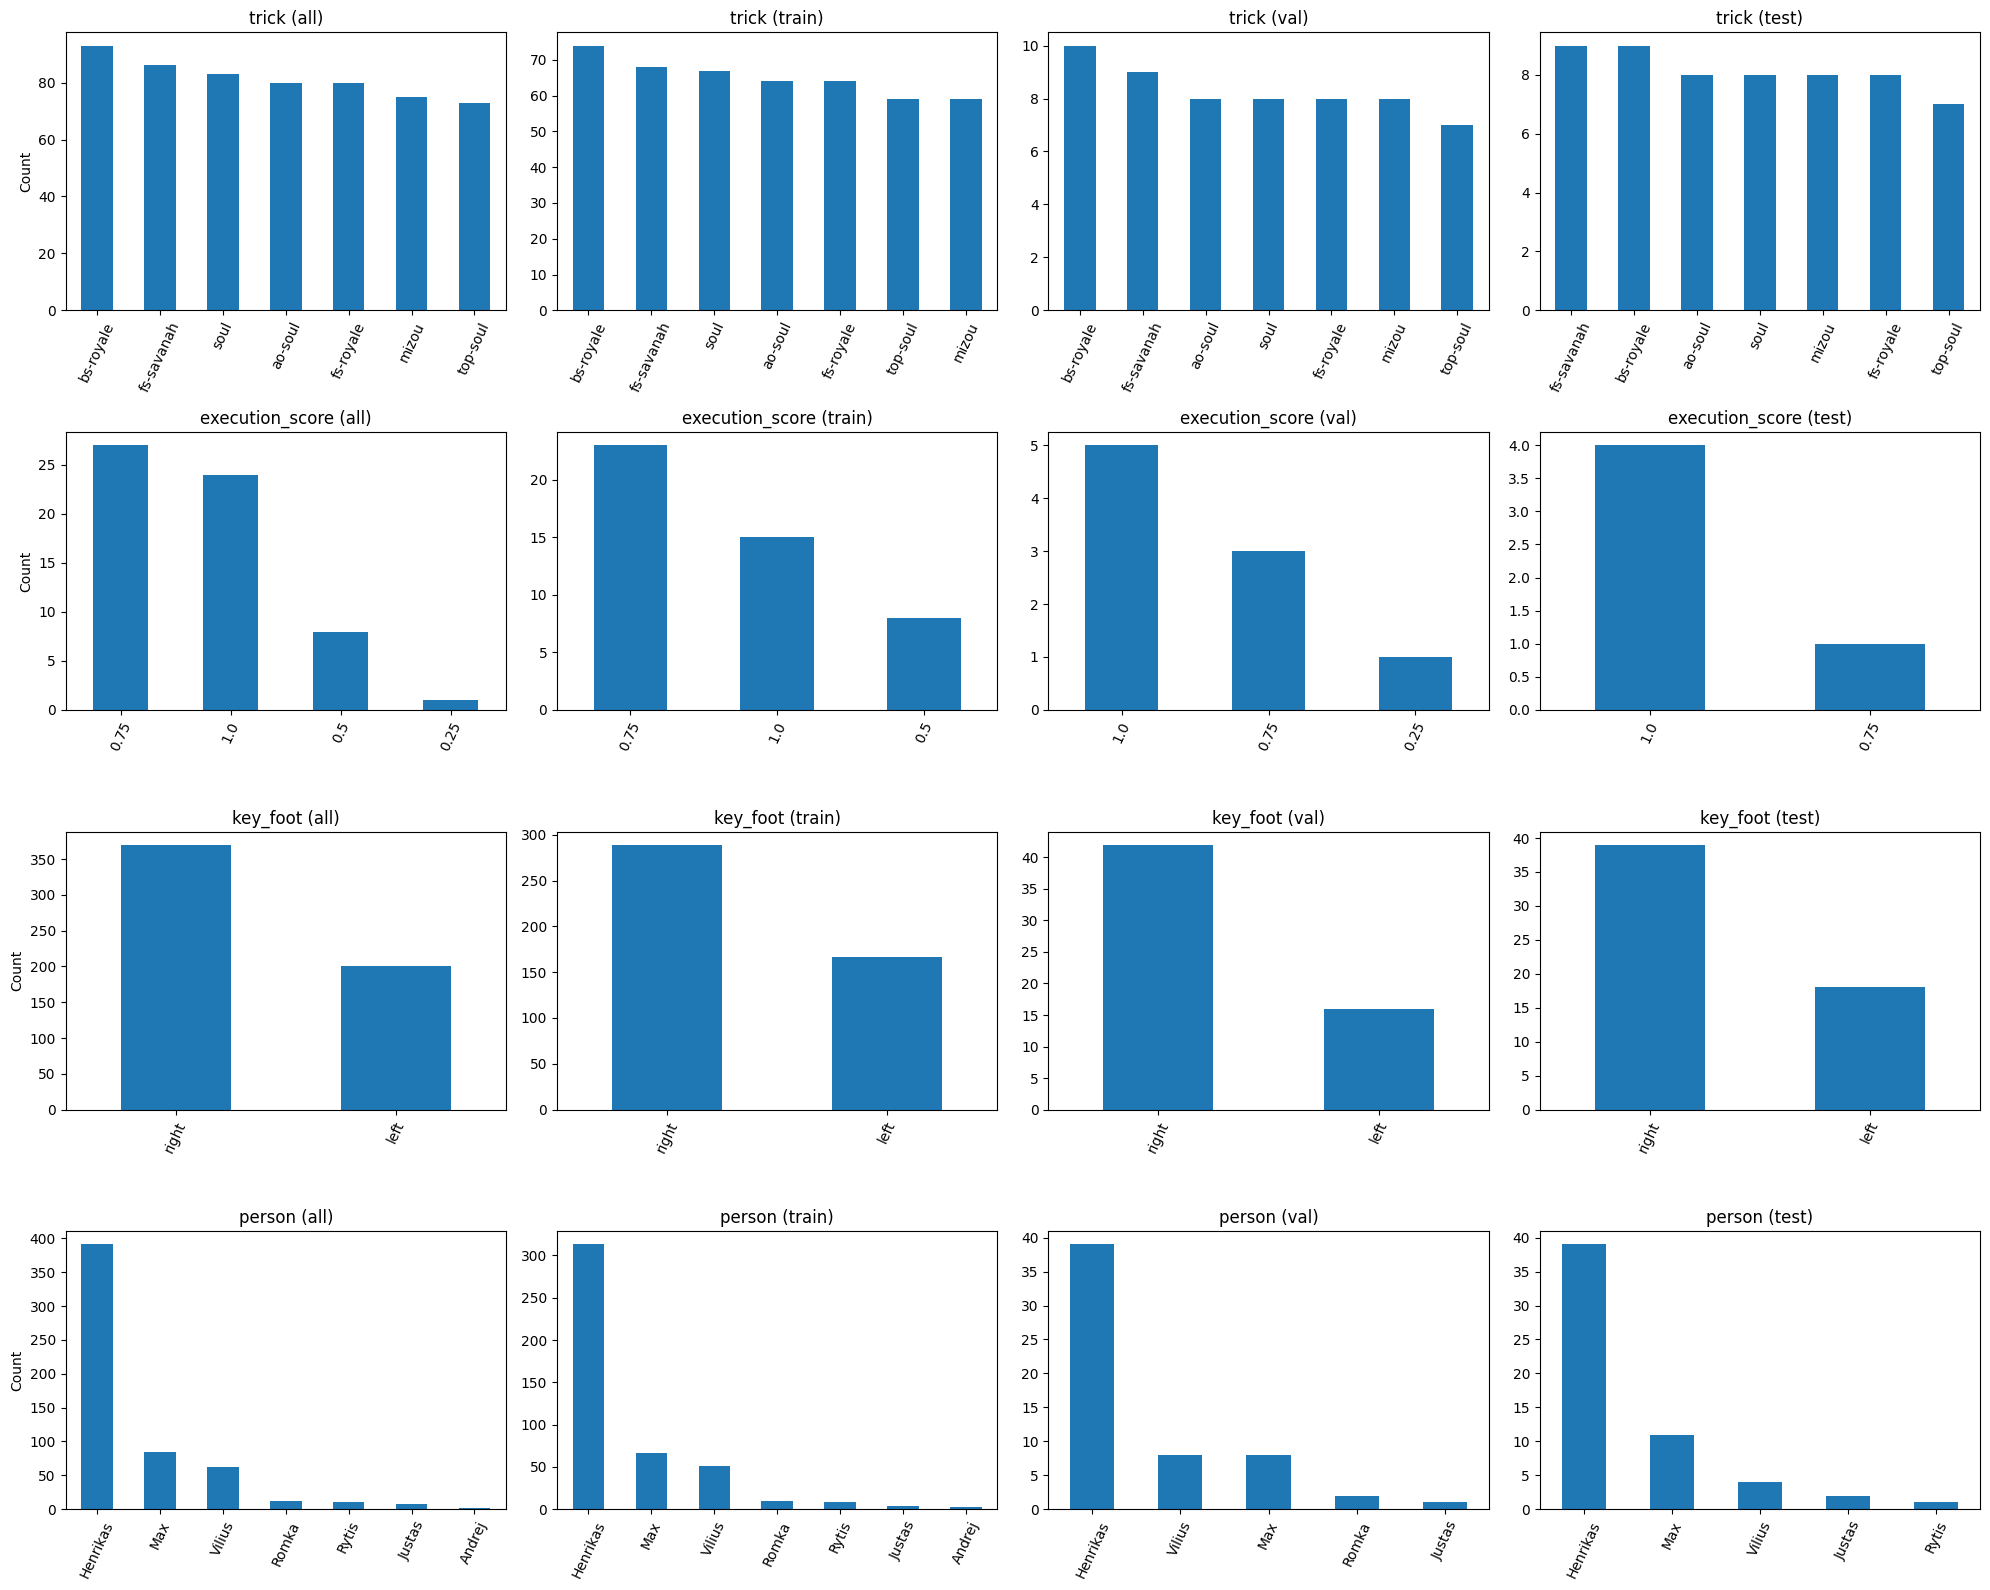

In [3]:
split_data = {"all": manifest_df}
split_data.update(split_frames)
num_cols = len(split_data)
fig, axes = plt.subplots(
    len(TRICK_TASK_COLUMNS),
    num_cols,
    figsize=(5 * num_cols, 4 * len(TRICK_TASK_COLUMNS)),
    squeeze=False,
)
for row, label_col in enumerate(TRICK_TASK_COLUMNS):
    for col_idx, (split_name, df) in enumerate(split_data.items()):
        ax = axes[row][col_idx]
        counts = df[label_col].value_counts().sort_values(ascending=False)
        counts.plot(kind="bar", ax=ax)
        ax.set_title(f"{label_col} ({split_name})")
        ax.set_xlabel("")
        ax.set_ylabel("Count" if col_idx == 0 else "")
        ax.tick_params(axis="x", rotation=65)
plt.tight_layout()
plt.show()

## Task: Score estimation


### Load manifests


In [4]:
SCORE_TASK_MANIFEST_DIR = MANIFEST_DIR / "score_prediction"
score_split_paths = {
    "train": SCORE_TASK_MANIFEST_DIR / "train.jsonl",
    "val": SCORE_TASK_MANIFEST_DIR / "val.jsonl",
    "test": SCORE_TASK_MANIFEST_DIR / "test.jsonl",
}
score_split_frames = {}
for split, path in score_split_paths.items():
    if not path.exists():
        raise FileNotFoundError(
            f"Missing manifest: {path}. Run the data pipeline first."
        )
    df = pd.read_json(path, lines=True)
    df["split"] = split
    score_split_frames[split] = df

score_manifest_df = pd.concat(score_split_frames.values(), ignore_index=True)
print("Score manifests rows per split:")
for split, df in score_split_frames.items():
    print(f"  {split}: {len(df)}")
score_manifest_df.head()


Score manifests rows per split:
  train: 48
  val: 6
  test: 6


,video_id,s3_path,execution_score,trick,key_foot,person,execution_explanation,split
0,25-12-02 21-20-36 5981-00.01.01.736-00.01.06.8...,s3://aitraf/clips/25-12-02 21-20-36 5981-00.01...,0.50,top-soul,left,Henrikas,"awkward landing, loss of control in the end",train
1,25-12-02 21-20-36 5981-00.01.24.845-00.01.30.5...,s3://aitraf/clips/25-12-02 21-20-36 5981-00.01...,0.75,top-soul,right,Henrikas,"full obstacle, but not perfectly balanced and ...",train
2,25-12-02 20-41-10 5974-00.14.02.131-00.14.07.4...,s3://aitraf/clips/25-12-02 20-41-10 5974-00.14...,1.00,top-soul,left,Henrikas,"good speed, control, stylish reverse landing b...",train
3,25-12-02 21-26-07 5982-00.09.04.288-00.09.09.1...,s3://aitraf/clips/25-12-02 21-26-07 5982-00.09...,0.75,ao-soul,left,Henrikas,"Controlled, good rotation, but shorter",train
4,25-12-02 20-41-10 5974-00.06.17.804-00.06.22.1...,s3://aitraf/clips/25-12-02 20-41-10 5974-00.06...,1.00,mizou,right,Max,"Great pose, the only downside its the landing ...",train


### Feature distribution across splits


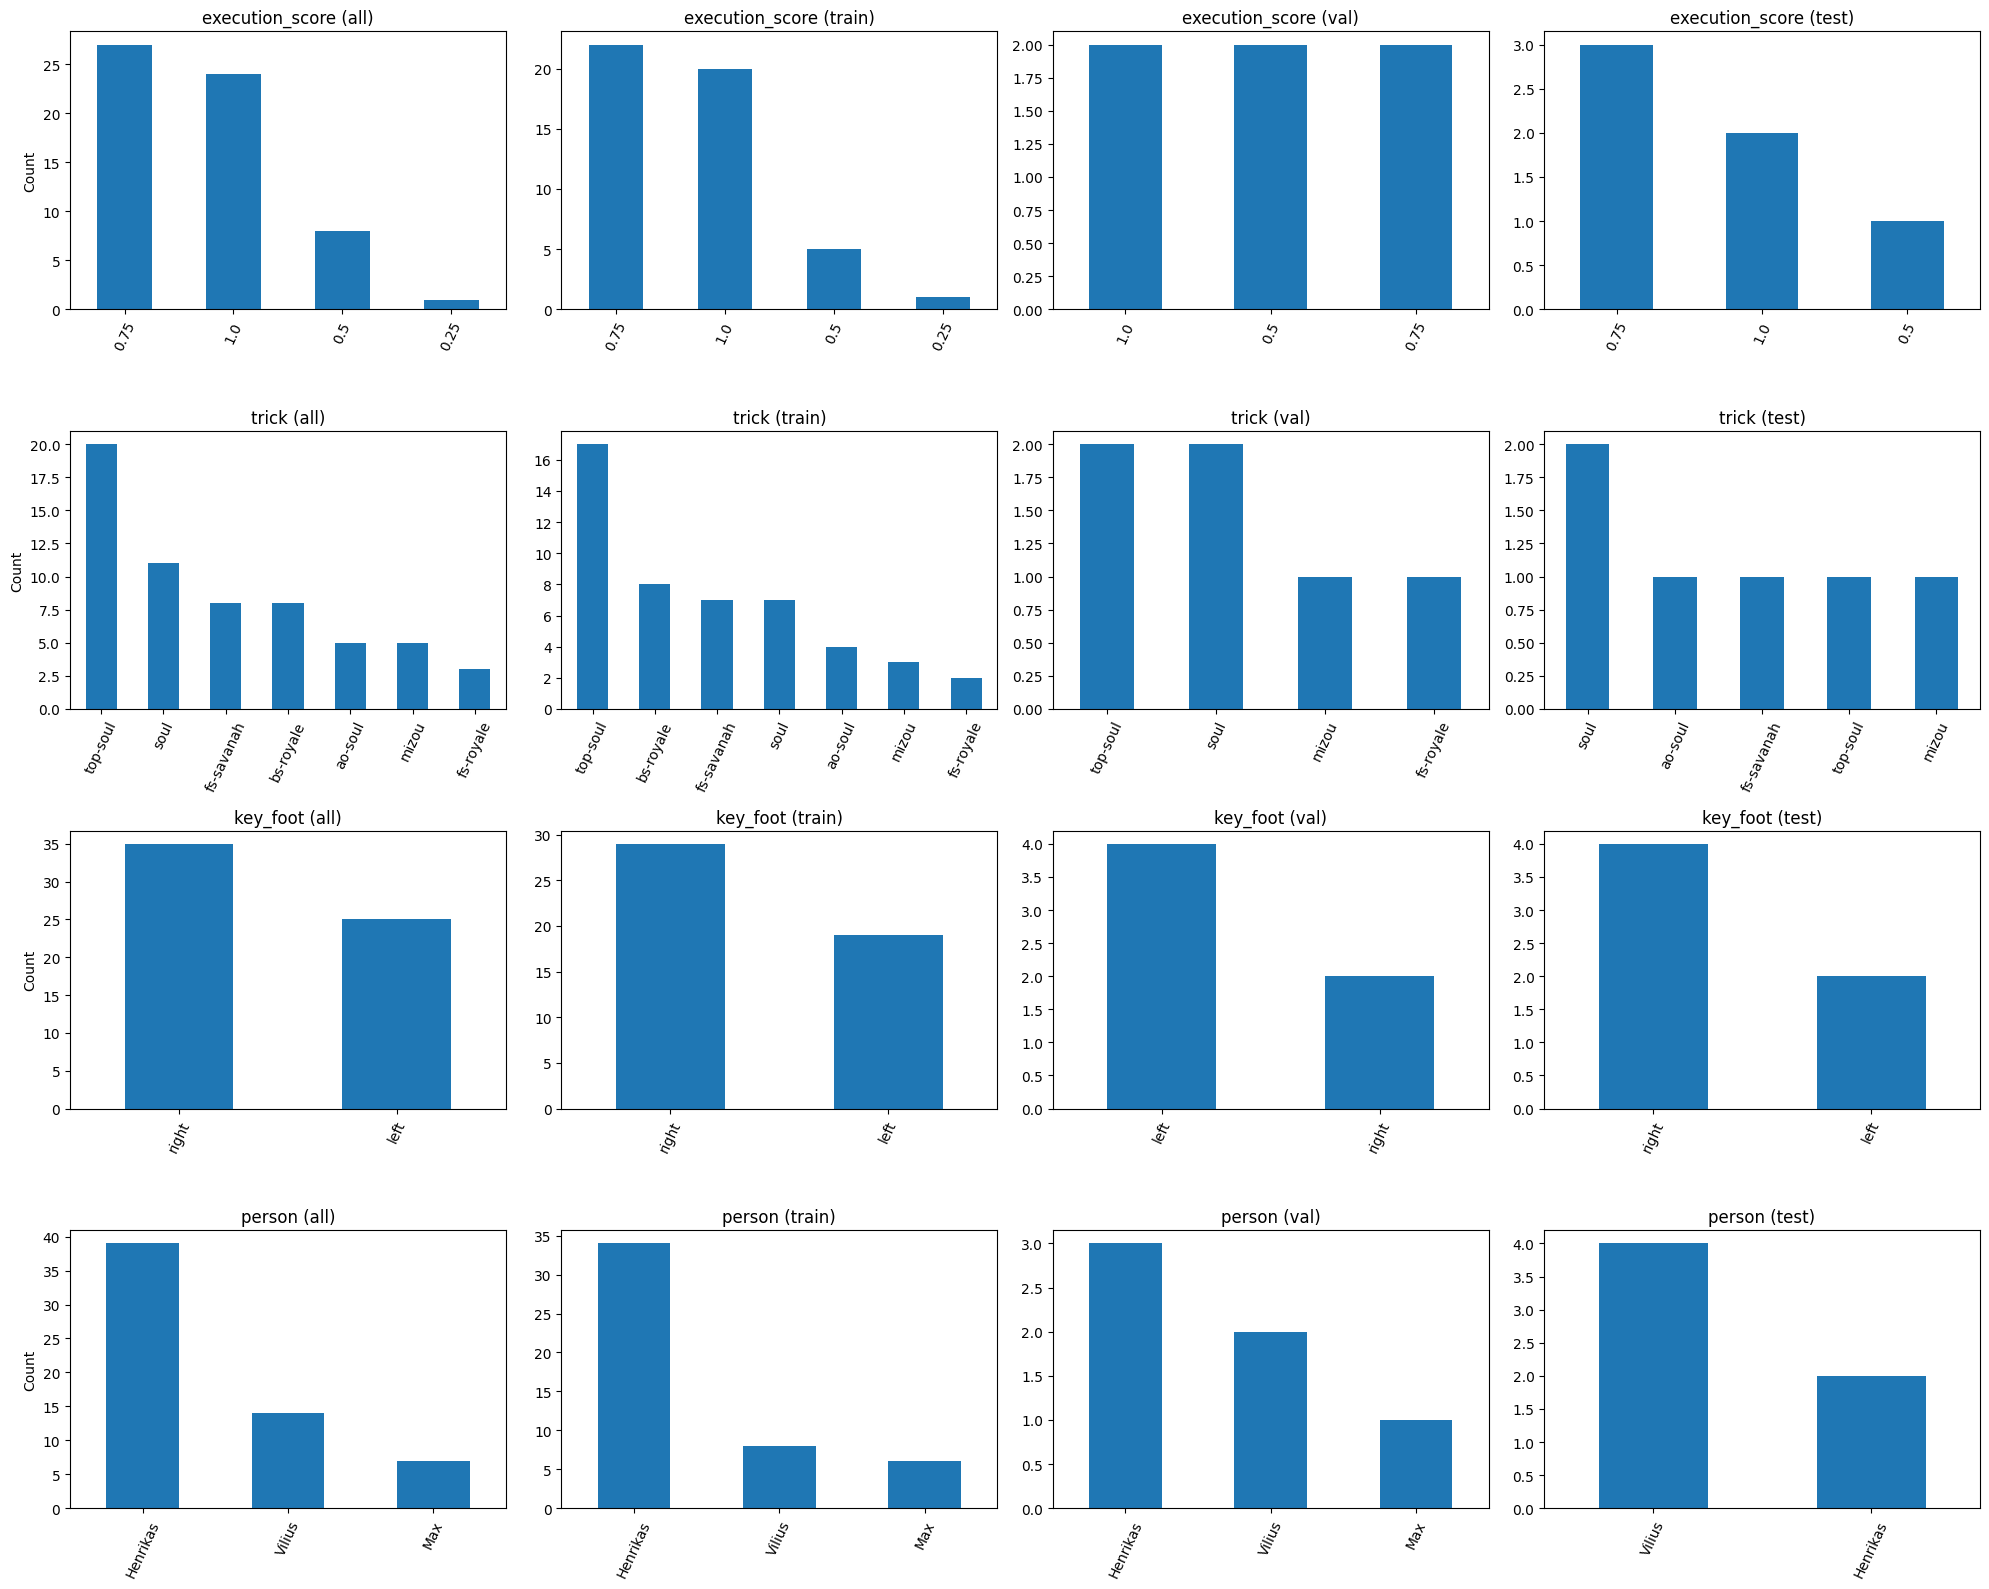

In [5]:
score_split_data = {"all": score_manifest_df}
score_split_data.update(score_split_frames)
num_cols = len(score_split_data)
fig, axes = plt.subplots(
    len(SCORE_TASK_COLUMNS),
    num_cols,
    figsize=(5 * num_cols, 4 * len(SCORE_TASK_COLUMNS)),
    squeeze=False,
)
for row, label_col in enumerate(SCORE_TASK_COLUMNS):
    for col_idx, (split_name, df) in enumerate(score_split_data.items()):
        ax = axes[row][col_idx]
        counts = df[label_col].value_counts().sort_values(ascending=False)
        counts.plot(kind="bar", ax=ax)
        ax.set_title(f"{label_col} ({split_name})")
        ax.set_xlabel("")
        ax.set_ylabel("Count" if col_idx == 0 else "")
        ax.tick_params(axis="x", rotation=65)
plt.tight_layout()
plt.show()
